In [33]:
import numpy as np
import pandas as pd
import json
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "stix",
    "font.size": 12
})

## Objective:
This code calculates the geometric definitions of the wing, hstab, and vstab given a number of inputs. 

The final definition is exported as a json in `geom_def`, where it can be parsed for further use.

### Parameter Definitions
From the T-S Diagram, we have the following main parameters:
- $S=465 \text{ft}^2$
- $W_0= 49,765 \text{lbs}$

We require an estimate for the fuselage length $L_{fuse}$. The RFP constrains us to a maximum fuselage length of 50ft. A preliminary estimate we use is:
- $L_{fuse}=45\text{ft}$

The maximum Mach number is also used in the calculation of a few parameters. The RFP specifies a minimum and desired top speed of 
- $M_{minimum}=1.6$
- $M_{desired}=2.0$ 

In [34]:
parm = {
    "S": 465,       #Wing Area, ft^2
    "W": 49765,     #MTOW/W_0, lb
    "L_fuse": 45,   #Fuselage length, ft
    "M": 1.6        #Top Speed, mach
}

### Planform defn
An arbitrary unswept wing surface can be defined with three parameters:
- Area $S$,
- Aspect Ratio $AR$,
- Taper Ratio $\lambda$

The function `planform` takes these three inputs, and returns:
- Span $b$,
- Root Chord $c_r$,
- Tip Chord $c_t$, 
- MAC $c_{bar}$, 

In [35]:
def planform(S, AR, lam):
    b = np.sqrt(S * AR)
    c_r = (2 * S) / (b * (1 + lam))
    c_t = lam * c_r
    c_bar = c_bar = (2/3) * c_r * (1 + lam + lam**2) / (1+lam)
    y_bar = (b / 6) * ((1 + 2 * lam) / (1 + lam))

    return b, c_r, c_t, c_bar, y_bar

planform(S=465, AR=2.85, lam=0.27)

(np.float64(36.40398329853479),
 np.float64(20.115476335700947),
 np.float64(5.431178610639256),
 np.float64(14.18009090352378),
 np.float64(7.357235469782622))

### Planform plotter
Given the planform defined by: 
- Span $b$,
- Root Chord $c_r$,
- Tip Chord $c_t$, 
- MAC $c_{bar}$, 
- Y loc of MAC $y_{bar}$
- LE Sweep $\Lambda_{LE}$,
- Offset $L$

The function `plan_plot` plots the surfaces, as well as a line for the MAC and 1/4MAC. The axes limits and labeling are left blank for the time being

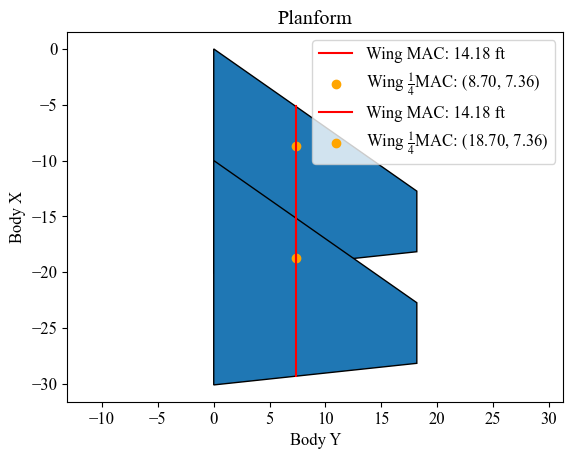

In [36]:
def plan_plot(b, c_r, c_t, c_bar, y_bar, LE_swp, L, n_surf, ax):
    LE_swp_rad = np.deg2rad(LE_swp)
    LE_s_bar = np.tan(LE_swp_rad)

    LE_point = (0, 0 -L)
    Tip_f_point = (b/2, -b/2 * LE_s_bar - L)
    Tip_b_point = (b/2, -b/2 * LE_s_bar - c_t - L)
    TE_point = (0, -c_r - L)

    points = [LE_point, Tip_f_point, Tip_b_point, TE_point]

    mac_line_x = (y_bar, y_bar)
    mac_line_y = (-(y_bar * LE_s_bar + L), -(y_bar * LE_s_bar + c_bar + L))

    quart_mac_x = y_bar
    quart_mac_y = -(y_bar * LE_s_bar + 0.25 * c_bar + L)

    #fig, ax = plt.subplots()
    trapezoid = patches.Polygon(points, closed=True,  edgecolor='black', fill=True)
    ax.add_patch(trapezoid)
    ax.plot(mac_line_x, mac_line_y, color="red", label=rf'{n_surf} MAC: {c_bar:.2f} ft')
    ax.scatter(quart_mac_x, quart_mac_y, color="orange", label=rf'{n_surf} $\frac{{1}}{{4}}$MAC: ({-quart_mac_y:.2f}, {quart_mac_x:.2f})')
    ax.axis('equal')
    ax.legend()
    ax.set_xlabel("Body Y")
    ax.set_ylabel("Body X")
    ax.set_title("Planform")

fig, ax = plt.subplots()
plan_plot(b=36.40, c_r=20.11, c_t=5.43, c_bar=14.18, y_bar=7.357, LE_swp=35, L=0, n_surf="Wing", ax=ax)
plan_plot(b=36.40, c_r=20.11, c_t=5.43, c_bar=14.18, y_bar=7.357, LE_swp=35, L=10, n_surf="Wing", ax=ax)


### Wing Planform Definition
The wing geometry can be defined with these parameters:
- Wing Area $S$
- Aspect Ratio $AR$
- Taper Ratio $\lambda$
- Leading Edge Sweep $\Lambda_{LE}$

We have previously chosen a preliminary aspect ratio:
- $AR=2.85$

We now select a preliminary taper ratio based on historical data (F/A-18E/F & F-35C):
- $\lambda=0.27$

The leading edge sweep $\Lambda_{LE}$ can be set based on the top speed:  

<img src="LE-sweep.png" alt="Description" width="600" height="400">

For now, we will just choose a preliminary value:
- $\Lambda_{LE} = 40$

In [37]:
wing_def = {
    "AR": 3.00,
    "lambda_w": 0.27,
    "LE_swp": 35    #LE Sweep, degree
}

{'b': np.float64(37.3496987939662),
 'S': 465,
 'c_r': np.float64(19.606141099194854),
 'c_t': np.float64(5.293658096782611),
 'c_bar': np.float64(13.82104298273426),
 'y_bar': np.float64(7.548364323190019),
 'LE_swp': 35,
 'quart_MAC_loc': (np.float64(8.74068234593445),
  np.float64(7.548364323190019))}

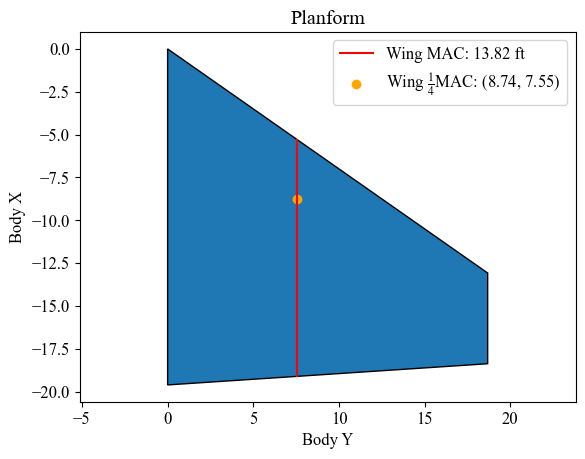

In [38]:
def wing_planform(S, AR, lambda_w, LE_swp):
    b_w, c_r, c_t, c_bar, y_bar = planform(S=S, AR=AR, lam=lambda_w)

    #Plotting
    LE_swp_rad = np.deg2rad(LE_swp)
    k = (b_w / 2) * np.tan(LE_swp_rad)

    mac_x = (y_bar, y_bar)
    mac_y = (-y_bar * np.tan(LE_swp_rad), -(y_bar * np.tan(LE_swp_rad) + c_bar))
    quart_mac = -(y_bar * np.tan(LE_swp_rad) + 0.25 * c_bar)

    '''points = [(0, 0), (b_w/2, -k), (b_w/2, -k-c_t), (0, -c_r)]

    fig, ax = plt.subplots()
    trapezoid = patches.Polygon(points, closed=True,  edgecolor='black', fill=True)
    ax.add_patch(trapezoid)
    #ax.set_xlabel("Body Y")
    #ax.set_ylabel("Body X")

    ax.plot(mac_x, mac_y, color='red', label=f"MAC={c_bar:.2f} ft")
    ax.scatter(y_bar, quart_mac, color="orange", label=rf"$\frac{{1}}{{4}}$MAC @ ({quart_mac:.2f}, {y_bar:.2f})")

    ax.set_xlim(0, b_w/2+1)
    ax.set_ylim(-c_r-9, 0)
    ax.axis('equal') 
    ax.legend()
    plt.show()'''

    wing_parm = {
        "b": b_w,
        "S": S,
        "c_r": c_r,
        "c_t": c_t,
        "c_bar": c_bar,
        'y_bar': y_bar,
        "LE_swp": LE_swp,
        "quart_MAC_loc": (-quart_mac, y_bar)
    }
    fig, ax = plt.subplots()
    plan_plot(b=b_w, c_r=c_r, c_t=c_t, c_bar=c_bar, y_bar=y_bar, LE_swp=LE_swp, L=0, n_surf="Wing", ax=ax)

    display(wing_parm)

    return wing_parm

wing_geom = wing_planform(S=parm["S"], **wing_def)

#### Wing Flaps and Ailerons
We are limited by the RFP to have a max folded wingspan of 35ft. This gives us a nice constraint for the max flap span allowed. Assuming 0.25ft for the folding mechanism, the flap max span is: 
- $b_{flap}/ b =  34.5 / b$

Allowing for around a six-foot width fuselage, we will assume that the flap starts at 3ft

We will take the flap chord to be: 
- $C_f/C = 0.35$

In [39]:
flap = {
    "b_1_flap": 4.2 / (wing_geom["b"]/2),
    "b_2_flap": 0.65,
    "cf_c_1": 0.25,
    "cf_c_2": 0.30
}

In [40]:
aileron = {
    "b1_ail": flap["b_2_flap"]+0.005,
    "b2_ail": wing_geom["b"]/2,
    "ca_c1": 0.2,
    "ca_c2": 0.25
}

In [41]:
slat = {
    "b1_slat": 0.23,
    "b2_slat": 1.0,
    "cs_c1": .15,
    "cs_c2": .2
}

### Hstab Definition
Raymer, Tbl. 6.4 gives values of $c_{HT}$ for a fighter.
- $c_{HT} = 0.40$

We also require the $AR$, $\lambda$, $\Lambda_{LE}$  
The aspect ratio for the hstab has a large variation based on historical data and provided guidelines from Raymer.
- $AR_{HT} = 2-4$  
Let's just select a value in the middle for now, 
- $AR_{HT} = 3$

The taper ratio $\lambda_{HT}$ is taken from average values from historical data, as well as Raymer tbl. 4.3
- $\lambda_{HT} = 0.3$

We select a leading edge sweep $\Lambda_{LE_{HT}}$ based on conservative historical data:
- $\Lambda_{LE_{HT}} = 35 \degree$

Historical values for the tail moment arm suggest a much shorter legnth than what Raymer suggest, around
- $L_{HT} = 0.3*L_{fuse}$

These values are tabulated below:

** A note on the elevator: 
- Raymer states; for supersonic aircraft, we usually have an all-moving tail. Hence, the Hstab will be all-moving, with no separate elevator surface.

In [42]:
Hstab_parm = {
    "c_HT": 0.38,
    "AR_HT": 3,
    "lambda_HT": 0.29, 
    "LE_swp_HT": 35,
    "L_HT": 0.37,
}

Hstab_loc = {
    "YLoc_HT": 2.2,
    "ZLoc_HT": -0.2
}

,b_HT,S_HT_tot,L_HT,c_r_HT,c_t_HT,c_bar_HT,y_bar_HT,LE_swp_HT,quart_mac_HT
0,20.976943,146.677375,16.65,10.840797,3.143831,7.698367,4.282115,35,4.922961
1,20.976943,146.677375,16.65,10.840797,3.143831,7.698367,4.282115,35,4.282115


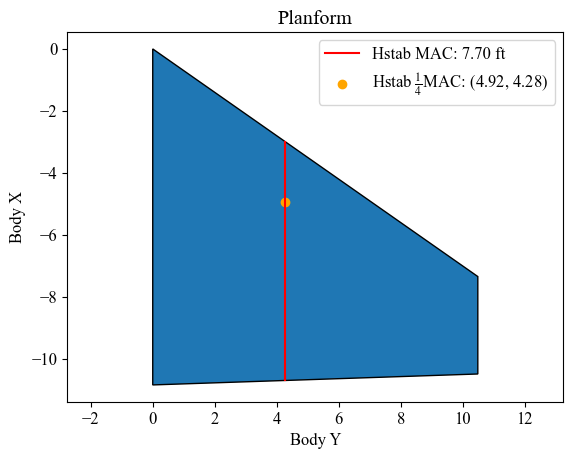

In [43]:
def hstab_planform(c_HT, AR_HT, lambda_HT, LE_swp_HT, L_HT, L_fuse, c_bar_w, S_w):
    L_arm_HT = L_HT * L_fuse
    #S_HT is the TOTAL hstab area required. Of course, for two hstabs, we would have half of that. 
    S_HT_tot = (c_HT * c_bar_w * S_w) / L_arm_HT

    #So, for a single tail surface, the area is: 
   # S_HT_single = S_HT_tot / 2

    b_HT, c_r_HT, c_t_HT, c_bar_HT, y_bar_HT = planform(S=S_HT_tot, AR=AR_HT, lam=lambda_HT)
    quart_c_bar_HT = 0.25 * c_bar_HT

    LE_swp_rad = np.deg2rad(LE_swp_HT)
    LE_swp_bar =  np.tan(LE_swp_rad)

    quart_mac_HT = -(y_bar_HT * np.tan(LE_swp_rad) + 0.25 * c_bar_HT)

    '''points = [(0, 0), (b_HT/2, -k), (b_HT/2, -k-c_t_HT), (0, -c_r_HT)]

    fig, ax = plt.subplots()
    trapezoid = patches.Polygon(points, closed=True,  edgecolor='black', fill=True)
    ax.add_patch(trapezoid)

    ax.set_xlim(0, b_HT/2+1)
    ax.set_ylim(-c_r_HT-9, 0)
    ax.axis('equal') '''

    fig, ax = plt.subplots()
    plan_plot(b=b_HT, c_r=c_r_HT, c_t=c_t_HT, c_bar=c_bar_HT, y_bar=y_bar_HT, LE_swp=LE_swp_HT, L=0, n_surf="Hstab", ax=ax)

    hstab_geom = {
        "b_HT": b_HT,
        "S_HT_tot": S_HT_tot,
        "L_HT": L_arm_HT,
        "c_r_HT": c_r_HT,
        "c_t_HT": c_t_HT,
        "c_bar_HT": c_bar_HT,
        "y_bar_HT": y_bar_HT,
        "LE_swp_HT": LE_swp_HT,
        "quart_mac_HT": (-quart_mac_HT, y_bar_HT)
    }
    hstab_geom_df = pd.DataFrame(hstab_geom)
    display(hstab_geom_df)
    return hstab_geom

hstab_geom = hstab_planform(**Hstab_parm, L_fuse=parm["L_fuse"], c_bar_w=wing_geom["c_bar"], S_w=parm['S'])

### Plotting the Wing & HStab together

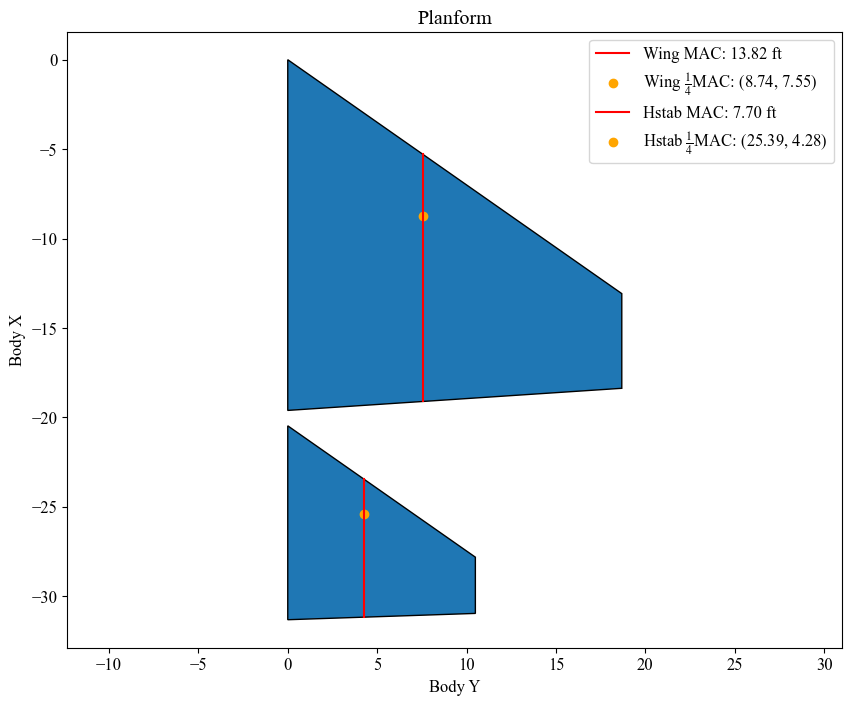

In [44]:
# Absolute distance from the Wing LE to the HStab LE is: the tail arm (L_HT), plus the x-location of the wing MAC (x_MAC), 
# minus the x-location (local) of the Hstab

def Wing_Hstab(wing_geom, hstab_geom):
    mac_x_wing, mac_y_wing = wing_geom["quart_MAC_loc"]
    mac_x_hstab, mac_y_hstab = hstab_geom["quart_mac_HT"]
    
    L_abs_HT = hstab_geom["L_HT"] + mac_x_wing - mac_x_hstab
    
    fig, ax = plt.subplots(figsize=(10,8))
    plan_plot(b=wing_geom["b"], c_r=wing_geom["c_r"], c_t=wing_geom["c_t"], c_bar=wing_geom["c_bar"],
               y_bar=wing_geom["y_bar"], LE_swp=wing_geom["LE_swp"], L=0, n_surf="Wing", ax=ax)
    plan_plot(b=hstab_geom["b_HT"], c_r=hstab_geom["c_r_HT"], c_t=hstab_geom["c_t_HT"], c_bar=hstab_geom["c_bar_HT"],
              y_bar=hstab_geom["y_bar_HT"], LE_swp=hstab_geom["LE_swp_HT"], L=L_abs_HT, n_surf="Hstab", ax=ax)
    plt.show()

Wing_Hstab(wing_geom, hstab_geom)

### VStab Definition
- The RFP limits maximum aircraft height at 18.5ft

Raymer, Tbl. 6.4 gives $c_{VT}$ for a fighter
- $c_{VT} = 0.07$

Based on Raymer, tbl. 4.3 and historical values, we select an aspect ratio for a single VStab as:
- $AR_{VT} = 1.3$

The taper ratio is selected based on historical data and Raymer, tbl 4.3:
- $\lambda_{VT} = 0.4$

The leading edge sweep is set according to historical data:
- $\Lambda_{LE_{VT}} = 40 \degree$

Historical values for the tail moment arm fraction suggest:
- $L_{VT} = 0.25 * L_{fuse}$

These values are tabulated below:

Further, some additional geometric parameters should be passed:
- Cant angle (measured from horizontal plane)
    - $X_{rot} = 70\degree$
- Horizontal offset (distance between two fins)
    - $Y_{loc} = 1.5$
- Vertical offset
    - $Z_{loc} = 0.25$



In [45]:
VStab_parm = {
    "c_VT": 0.08,
    "AR_VT": 1.35,
    "lambda_VT": 0.4,
    "LE_swp_VT": 40,
    "L_VT_frac": 0.30
}

VStab_geom_parm = {
    "Y_loc": 2.5,
    "Z_loc": 0.25,
    "X_rot": 70
}

,b_VT,S_VT_tot,L_VT,c_r_VT,c_t_VT,c_bar_VT,y_bar_VT,LE_swp_VT,quart_mac_VT
0,16.669786,102.91917,13.5,8.819992,3.527997,6.551994,3.572097,40,4.635344
1,16.669786,102.91917,13.5,8.819992,3.527997,6.551994,3.572097,40,3.572097


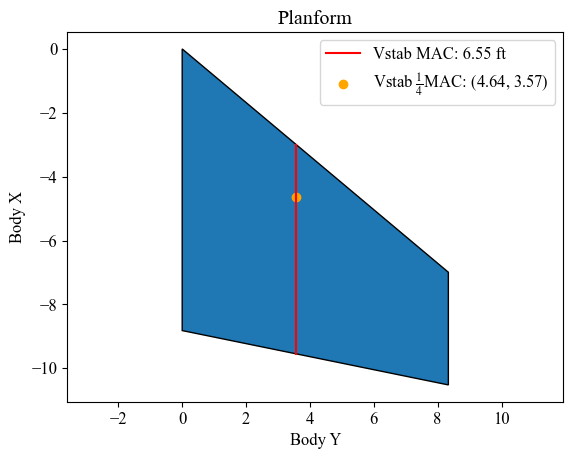

In [46]:
def VStab_planform(c_VT, AR_VT, lambda_VT, LE_swp_VT, L_VT_frac, L_fuse, b_w, S_w, cr_c):
    L_VT = L_fuse * L_VT_frac
    S_VT_tot = (c_VT * b_w * S_w) / L_VT

    b_VT, c_r_VT, c_t_VT, c_bar_VT, y_bar_VT = planform(S=S_VT_tot, AR=2*AR_VT, lam=lambda_VT)

    quart_mac_VT = (y_bar_VT * np.tan(np.deg2rad(LE_swp_VT)) + 0.25 * c_bar_VT)

    fig, ax = plt.subplots()
    plan_plot(b=b_VT, c_r=c_r_VT, c_t=c_t_VT, c_bar=c_bar_VT, y_bar=y_bar_VT, LE_swp=LE_swp_VT, L=0, n_surf="Vstab", ax=ax)

    VStab_geom = {
        "b_VT": b_VT,
        "S_VT_tot": S_VT_tot,
        "L_VT": L_VT,
        "c_r_VT": c_r_VT,
        "c_t_VT": c_t_VT,
        "c_bar_VT": c_bar_VT,
        "y_bar_VT": y_bar_VT,
        "LE_swp_VT": LE_swp_VT,
        "quart_mac_VT": (quart_mac_VT, y_bar_VT)
    }
    vstab_geom_df = pd.DataFrame(VStab_geom)
    display(vstab_geom_df)
    return VStab_geom

vstab_geom = VStab_planform(**VStab_parm, L_fuse=parm["L_fuse"], b_w=wing_geom["b"], S_w=parm["S"], cr_c=0.3)

#### Rudder Definition
For the control surfaces, Raymer gives the following guidelines: 
- $C_r/C = 0.3$
We will arbitrarily declare that the surface begins from $0.05b_{VT}$, and goes full span.

In [47]:
rud = {
    "cr_c": 0.3,
    "b1_rud": 0.1,
    "b2_rud": 1.0
}

### Plotting Wing, V&Hstab together:

Absolute Distance from Wing LE to HStab LE: 20.4677
Absolute Distance from Wing LE to VStab LE: 17.6053


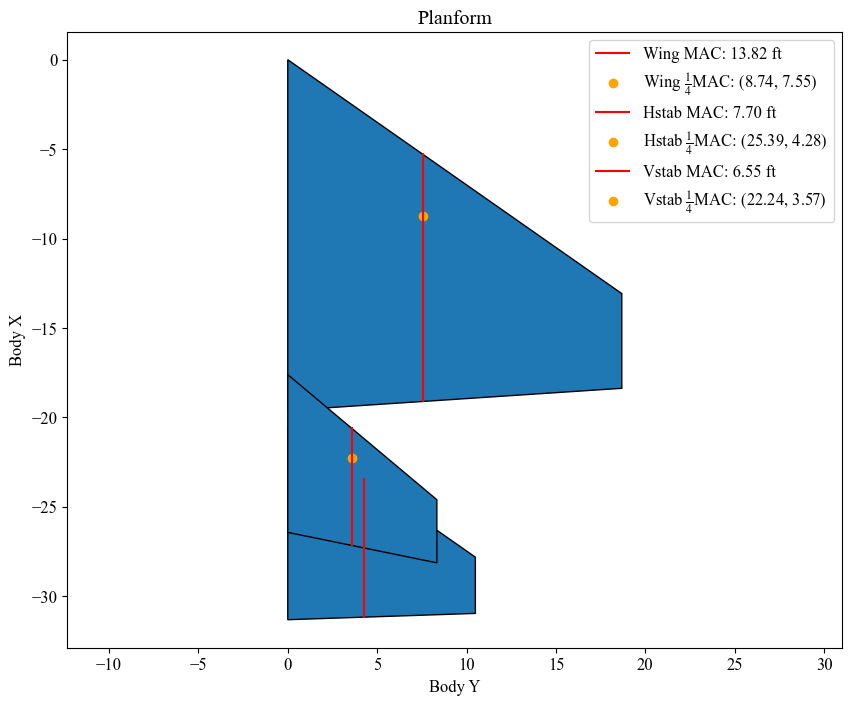

In [48]:
# Absolute distance from the Wing LE to the HStab LE is: the tail arm (L_HT), plus the x-location of the wing MAC (x_MAC), 
# minus the x-location (local) of the Hstab

def Wing_HVstab(wing_geom, hstab_geom, vstab_geom):
    mac_x_wing, mac_y_wing = wing_geom["quart_MAC_loc"]
    mac_x_hstab, mac_y_hstab = hstab_geom["quart_mac_HT"]
    mac_x_vstab, mac_y_vstab = vstab_geom["quart_mac_VT"]
    
    L_abs_HT = hstab_geom["L_HT"] + mac_x_wing - mac_x_hstab
    print(f"Absolute Distance from Wing LE to HStab LE: {L_abs_HT:.4f}")
    L_abs_VT = vstab_geom["L_VT"] + mac_x_wing - mac_x_vstab
    print(f"Absolute Distance from Wing LE to VStab LE: {L_abs_VT:.4f}")
    
    fig, ax = plt.subplots(figsize=(10,8))
    plan_plot(b=wing_geom["b"], c_r=wing_geom["c_r"], c_t=wing_geom["c_t"], c_bar=wing_geom["c_bar"],
               y_bar=wing_geom["y_bar"], LE_swp=wing_geom["LE_swp"], L=0, n_surf="Wing", ax=ax)
    plan_plot(b=hstab_geom["b_HT"], c_r=hstab_geom["c_r_HT"], c_t=hstab_geom["c_t_HT"], c_bar=hstab_geom["c_bar_HT"],
              y_bar=hstab_geom["y_bar_HT"], LE_swp=hstab_geom["LE_swp_HT"], L=L_abs_HT, n_surf="Hstab", ax=ax)
    plan_plot(b=vstab_geom["b_VT"], c_r=vstab_geom["c_r_VT"], c_t=vstab_geom["c_t_VT"], c_bar=vstab_geom["c_bar_VT"],
              y_bar=vstab_geom["y_bar_VT"], LE_swp=vstab_geom["LE_swp_VT"], L=L_abs_VT, n_surf="Vstab", ax=ax)
    plt.show()

    return L_abs_HT, L_abs_VT

L_LE_HT, L_LE_VT = Wing_HVstab(wing_geom, hstab_geom, vstab_geom)

### Weights - Wing
Raymer Eq. 15.1 gives statistical equations to estimate the weight of the wing. 
$\begin{equation}
W_{wing} = 0.0103K_{dw}K_{vs}(W_{dg}N_z)^{0.5}S_{w}^{0.622}A^{0.785}(t/c)_{root}\times (1+\lambda)^{0.05}(\text{cos}\Lambda)^{-1.0}S_{csw}^{0.04}
\end{equation}$

Where:
- $K_{dw} = 1.0$
- $K_{vs} = 1.0$
- $W_{dg}$: Flight Design Gross Weight (typically 50-60% internal fuel)
- $N_z = 7 * 1.5 = 10.5$
- $S_w$: Trapezoidal Wing Area (incl. fuse area)
- $A$: Aspect Ratio
- $(t/c)_{root}$: Airfoil thickness at root
- $\lambda$: Taper Ratio
- $\Lambda$: Wing Sweep at 25% MAC
- $S_{csw}$: Control surface area

### Weights - HStab
Raymer Eq. 15.2 statistically estimates hstab weight:
$\begin{equation}
W_{HT}=3.316\bigg( 1 + \frac{F_w}{B_h} \bigg)^{-2.0}\bigg( \frac{W_{dg}N_z}{1000} \bigg)^{0.260}S_{ht}^{0.806}
\end{equation}$

Where: 
- $F_w$: Fuselage width at horizontal tail intersection
- $B_h$: Horiz. tail span
- $W_{dg}$: Flight Design Gross Weight (typically 50-60% internal fuel)
- $N_z = 10.5$
- $S_{ht}$: Horiz. tail area

### Weights - VStab
Raymer Eq. 15.3 statistically estimates hstab weight:
$\begin{equation}
W_{VT} = 0.452K_{rht}(1 + H_t/H_v)^{0.5}(W_{dg}N_z)^{0.488}S_{vt}^{0.718}M^{0.341}\times L_{t}^{-1.0}(1+S_r/S_{vt})^{0.348}A_{vt}^{0.233} \times (1+\lambda)^{0.25}(\text{cos}\Lambda_{vt})^{-0.323}
\end{equation}$

Where: 
- $K_{rht} = 1.0$
- $H_t/H_v = 0$
- $W_{dg}$: Flight Design Gross Weight (typically 50-60% internal fuel)
- $N_z = 10.5$
- $S_{vt}$: Vertical Tail Area
- $M$: Design max mach number
- $L_t$: Tail length; wing quarter-MAC to tail quarter-MAC
- $S_r$: Rudder Area
- $A_{vt}$: Aspect Ratio, vertical tail
- $\lambda$: Taper Ratio, vertical tail
- $\Lambda_{vt}$: Sweep at 25% MAC, vertical tail

### Export to JSON for openVSP geometry script

In [49]:
geom_def = {
    "wing": {
        "b_w": float(wing_geom["b"]),
        "ar_w": float(wing_def["AR"]),
        "S_w": float(parm["S"]),
        "lamb_w": float(wing_def["lambda_w"]),
        "c_r_w": float(wing_geom["c_r"]),
        "c_t_w": float(wing_geom["c_t"]),
        "swp_w": float(wing_geom["LE_swp"]),
        "flap_1_span": float(flap["b_1_flap"]),
        "flap_2_span": float(flap["b_2_flap"]),
        "flap_c_frac1": float(flap["cf_c_1"]),
        "flap_c_frac2": float(flap["cf_c_2"]),
        "ail_1_span": float(aileron["b1_ail"]),
        "ail_2_span": float(aileron["b2_ail"]),
        "ail_c_frac1": float(aileron["ca_c1"]),
        "ail_c_frac2": float(aileron["ca_c2"]),
        "slat_1_span": float(slat["b1_slat"]),
        "slat_2_span": float(slat["b2_slat"]),
        "slat_c_frac1": float(slat["cs_c1"]),
        "slat_c_frac2": float(slat["cs_c2"])
    },
    "hstab": {
        "b_HT": float(hstab_geom["b_HT"]),
        "S_HT": float(hstab_geom["S_HT_tot"]),
        "c_r_HT": float(hstab_geom["c_r_HT"]),
        "c_t_HT": float(hstab_geom["c_t_HT"]),
        "swp_HT": float(hstab_geom["LE_swp_HT"]),
        "x_loc_HT": float(L_LE_HT),
        "Y_loc": float(Hstab_loc["YLoc_HT"]),
        "Z_loc": float(Hstab_loc["ZLoc_HT"])
    },
    "vstab": {
        "b_VT": float(vstab_geom["b_VT"]),
        "S_VT": float(vstab_geom["S_VT_tot"]),
        "AR_VT": float(VStab_parm["AR_VT"]),
        "c_r_VT": float(vstab_geom["c_r_VT"]),
        "c_t_VT": float(vstab_geom["c_t_VT"]),
        "swp_VT": float(vstab_geom["LE_swp_VT"]),
        "lam_VT": float(VStab_parm["lambda_VT"]),
        "L_VT": float(vstab_geom["L_VT"]),
        "rud_c_frac": float(rud["cr_c"]),
        "rud_1_span": float(rud["b1_rud"]),
        "rud_2_span": float(rud["b2_rud"]),
        "x_loc_VT": float(L_LE_VT),
        "Y_loc": float(VStab_geom_parm["Y_loc"]),
        "Z_loc": float(VStab_geom_parm["Z_loc"]),
        "X_rot": float(VStab_geom_parm["X_rot"]),
    }
}

vsp_dir = "/Users/ryuyaiwase/Desktop/OpenVSP-3.47.0-MacOS/python/EAE130"
json_path = os.path.join(vsp_dir, "airplane_geom.json")

with open(json_path, "w") as json_file:
    json.dump(geom_def, json_file, indent=4)

print(f"Succesfully saved to {json_path}")

Succesfully saved to /Users/ryuyaiwase/Desktop/OpenVSP-3.47.0-MacOS/python/EAE130/airplane_geom.json
